# Causalidad entre Variables Financieras con Grafos

Taller B3-T3 — Descubrimiento de estructura causal sobre variables macro (SP500, VIX, Oro, Bonos, Dolar)  
usando Grafos Acíclicos Dirigidos (DAG). Se compara correlacion simetrica vs causalidad dirigida.

## 0. Instalacion

Instala las dependencias necesarias si no estan disponibles en el entorno.

In [31]:
# Instala todas las dependencias del proyecto en silencio
!pip install pgmpy yfinance networkx matplotlib pandas numpy scikit-learn seaborn lingam statsmodels plotly --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

Carga todas las librerias del proyecto. `warnings` suprime los FutureWarning de pgmpy.

In [32]:
import warnings
warnings.filterwarnings('ignore')       # suprime FutureWarnings de pgmpy

import pandas as pd                     # tablas de datos
import numpy as np                      # operaciones numericas
import matplotlib.pyplot as plt         # graficos estaticos
import seaborn as sns                   # heatmaps
import networkx as nx                   # grafos dirigidos
import yfinance as yf                   # descarga datos de Yahoo Finance
import plotly.graph_objects as go       # grafico interactivo

from pgmpy.estimators import PC, HillClimbSearch  # algoritmos causales
from sklearn.linear_model import LinearRegression  # regresion lineal
from statsmodels.tsa.stattools import grangercausalitytests  # test de Granger
import lingam                            # algoritmo LiNGAM (ICA)

## 1. Datos y Correlacion de Pearson

Descarga retornos diarios (2000-2024) y muestra la matriz de Pearson -- simetrica, sin direccion causal.

[*********************100%***********************]  5 of 5 completed


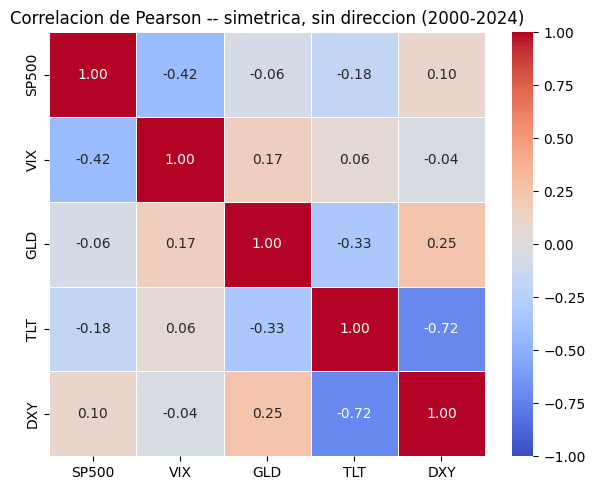

In [33]:
# Tickers de Yahoo Finance para los 5 activos macro
tickers = ['^GSPC', '^VIX', 'GLD', 'TLT', 'DX-Y.NYB']
names   = ['SP500', 'VIX', 'GLD', 'TLT', 'DXY']         # nombres legibles

# Descarga precios de cierre ajustados 2000-2024
raw = yf.download(tickers, start='2000-01-01', end='2024-12-31', auto_adjust=True)['Close']
raw.columns = names                     # renombra columnas
returns = raw.pct_change().dropna()     # convierte precios a retornos diarios y elimina NaN

# Calcula la matriz de correlacion de Pearson (simetrica)
corr = returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
# Pinta la correlacion como heatmap: rojo=positiva, azul=negativa
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlacion de Pearson -- simetrica, sin direccion (2000-2024)')
plt.tight_layout(); plt.show()

## 2. DAG -- Algoritmo PC

PC elimina aristas por independencia condicional y orienta colisionadores. Grafo dirigido + matriz de adyacencia asimetrica.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 50.07it/s] 


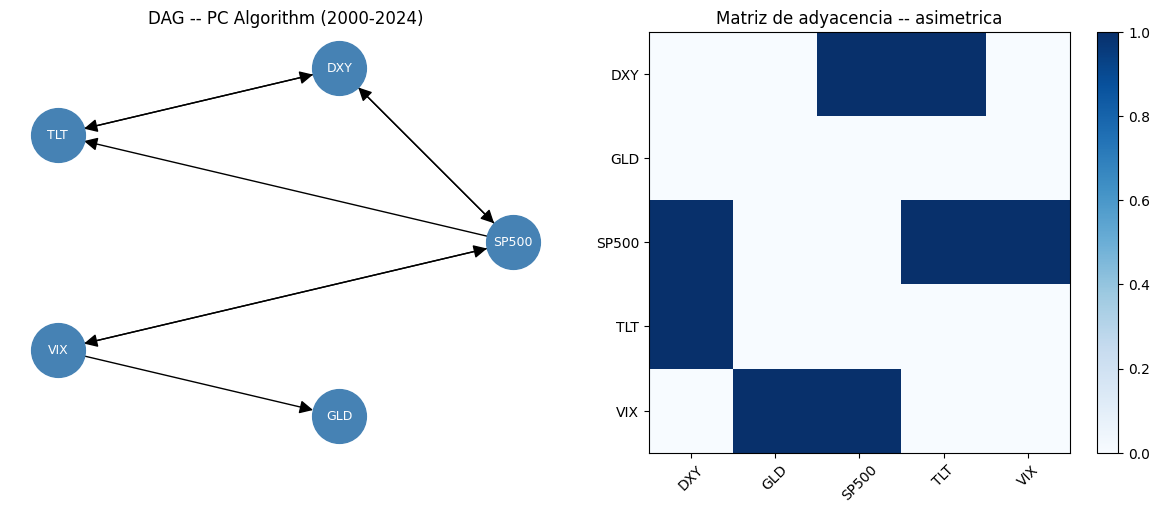

In [ ]:
# Funcion auxiliar para dibujar un DAG con networkx
def draw_dag(dag, title, ax):
    G = nx.DiGraph(dag.edges()); G.add_nodes_from(dag.nodes())  # crea grafo dirigido
    pos = nx.circular_layout(G)          # posiciona nodos en circulo
    nx.draw_networkx(G, pos, ax=ax, node_color='steelblue', node_size=1500,
                     font_color='white', edge_color='black', arrows=True, arrowsize=20, font_size=9)
    ax.set_title(title); ax.axis('off')  # quita ejes

# Ejecuta el algoritmo PC sobre los retornos completos (2000-2024)
# ci_test='pearsonr': test de independencia condicional con correlacion de Pearson
# significance_level=0.05: umbral para eliminar una arista
dag_pc = PC(data=returns).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

# Construye la matriz de adyacencia numerica a partir del DAG
nodes = sorted(dag_pc.nodes())           # nodos en orden alfabetico
G_dir = nx.DiGraph(dag_pc.edges()); G_dir.add_nodes_from(dag_pc.nodes())
adj = nx.to_numpy_array(G_dir, nodelist=nodes)  # 1 si existe arista, 0 si no

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_dag(dag_pc, 'DAG -- PC Algorithm (2000-2024)', axes[0])  # panel izquierdo: grafo
im = axes[1].imshow(adj, cmap='Blues')   # panel derecho: matriz de adyacencia
axes[1].set_xticks(range(len(nodes))); axes[1].set_xticklabels(nodes, rotation=45)
axes[1].set_yticks(range(len(nodes))); axes[1].set_yticklabels(nodes)
axes[1].set_title('Matriz de adyacencia -- asimetrica')
plt.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()

## 3. Estabilidad temporal -- PC por periodos

Compara la estructura causal en 4 ventanas: pre/post-crisis 2008 y bull/bear market.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 126.33it/s]


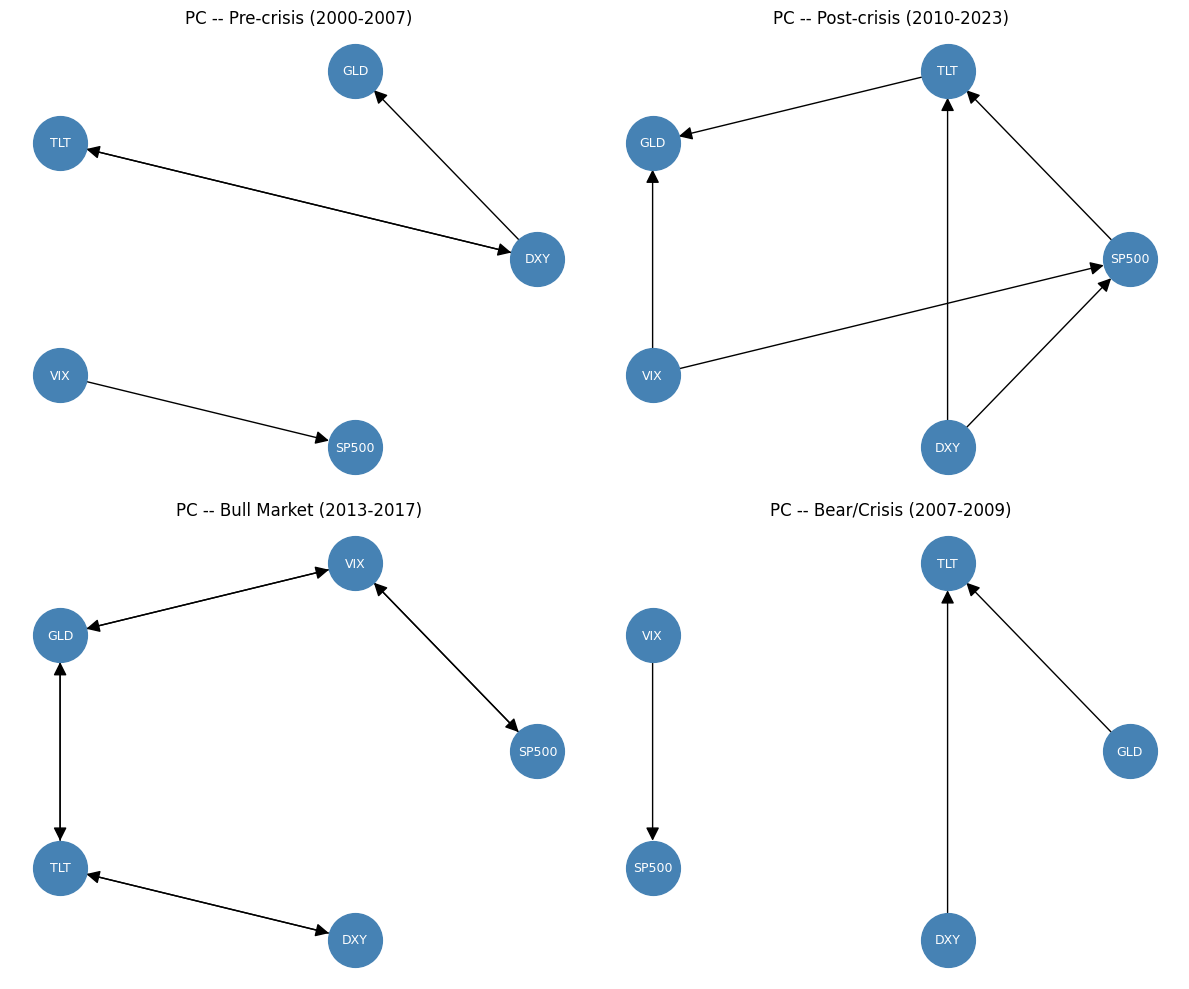

In [35]:
# Filtra los retornos por ventana temporal (excluye 2008-2009 de pre/post)
ret_pre  = returns.loc['2000-01-01':'2007-12-31']  # antes de la crisis
ret_post = returns.loc['2010-01-01':'2023-12-31']  # despues de la crisis
ret_bull = returns.loc['2013-01-01':'2017-12-31']  # mercado alcista
ret_bear = returns.loc['2007-01-01':'2009-12-31']  # mercado bajista / crisis

# Aplica PC independientemente en cada ventana temporal
dag_pre  = PC(data=ret_pre ).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_post = PC(data=ret_post).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_bull = PC(data=ret_bull).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
dag_bear = PC(data=ret_bear).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

# Muestra los 4 grafos en una figura 2x2 para comparar directamente
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
draw_dag(dag_pre,  'PC -- Pre-crisis (2000-2007)',  axes[0,0])  # arriba-izquierda
draw_dag(dag_post, 'PC -- Post-crisis (2010-2023)', axes[0,1])  # arriba-derecha
draw_dag(dag_bull, 'PC -- Bull Market (2013-2017)', axes[1,0])  # abajo-izquierda
draw_dag(dag_bear, 'PC -- Bear/Crisis (2007-2009)', axes[1,1])  # abajo-derecha
plt.tight_layout(); plt.show()

## 4. Comparacion de algoritmos causales

PC (constraint-based) vs HillClimbSearch (score-based, BIC) vs LiNGAM (ICA, colas gordas).

  0%|          | 7/1000000 [00:00<9:07:16, 30.45it/s] 


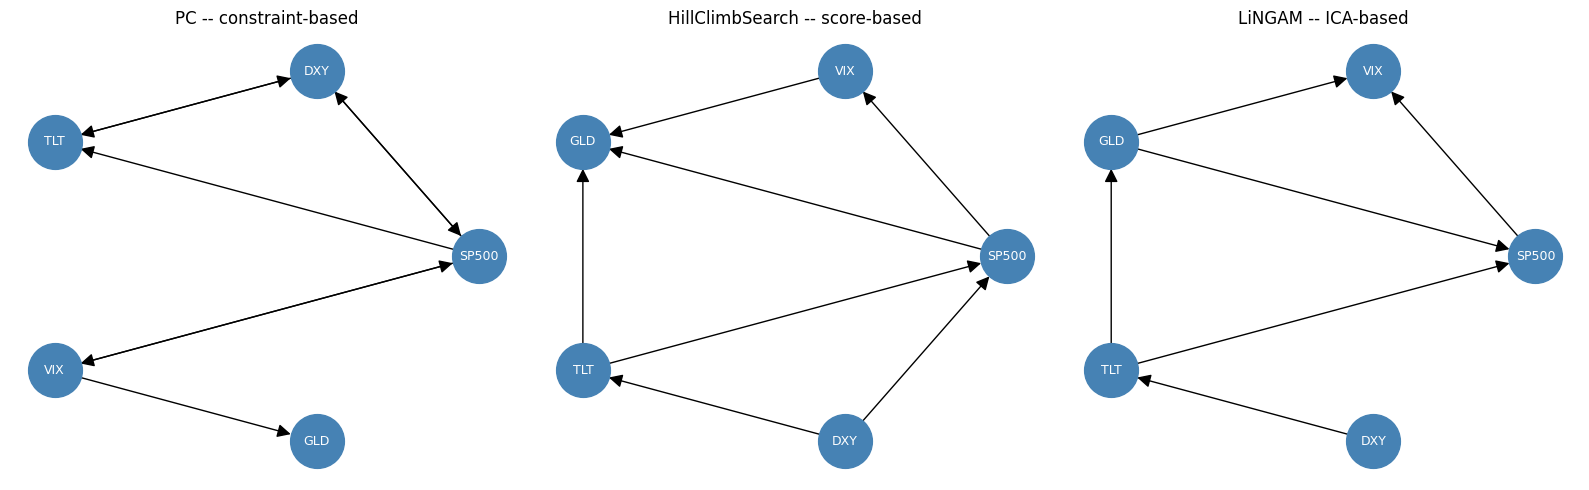

In [36]:
# HillClimbSearch: maximiza BIC de forma greedy (score-based)
dag_hcs = HillClimbSearch(data=returns).estimate(scoring_method='bic-g')

# LiNGAM: usa ICA para explotar las colas gordas de los retornos (no-gaussianidad)
model_ling = lingam.DirectLiNGAM()
model_ling.fit(returns.values)           # ajusta el modelo sobre la matriz de retornos
G_l = nx.DiGraph(); G_l.add_nodes_from(returns.columns)  # grafo vacio con los 5 nodos
for i, src in enumerate(returns.columns):
    for j, tgt in enumerate(returns.columns):
        # añade arista si el coeficiente causal supera el umbral 0.05
        if abs(model_ling.adjacency_matrix_[j, i]) > 0.05:
            G_l.add_edge(src, tgt)

# Figura 1x3: los tres algoritmos lado a lado para comparar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
draw_dag(dag_pc,  'PC -- constraint-based',         axes[0])  # panel 1
draw_dag(dag_hcs, 'HillClimbSearch -- score-based', axes[1])  # panel 2
pos = nx.circular_layout(G_l)           # posicion circular para LiNGAM
nx.draw_networkx(G_l, pos, ax=axes[2], node_color='steelblue', node_size=1500,
                 font_color='white', edge_color='black', arrows=True, arrowsize=20, font_size=9)
axes[2].set_title('LiNGAM -- ICA-based'); axes[2].axis('off')  # panel 3
plt.tight_layout(); plt.show()

## 5. Causalidad temporal -- Granger y PC lag-1

Granger: p < 0.05 indica que el pasado de X predice Y. PC lag-1: arista X_lag1->Y confirma precedencia temporal.

Working for n conditional variables: 5: 100%|██████████| 5/5 [00:00<00:00,  5.64it/s]


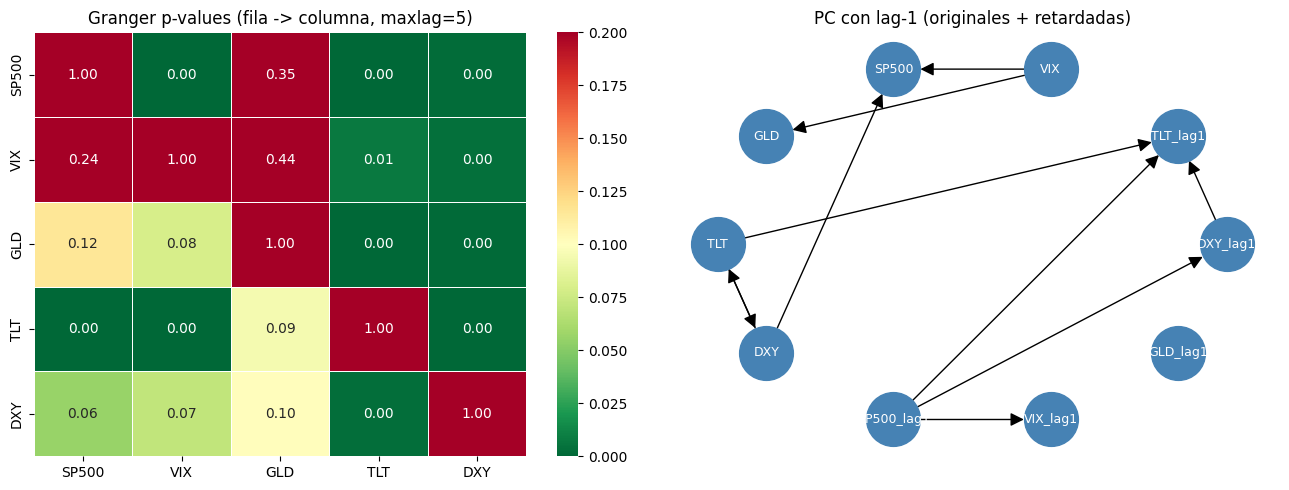

In [37]:
# Lista de columnas para iterar sobre todos los pares
cols = returns.columns.tolist()
# Inicializa la matriz de p-values con 1.0 (hipotesis nula: no hay causalidad)
pval = pd.DataFrame(np.ones((5, 5)), index=cols, columns=cols)
for r in cols:
    for c in cols:
        if r != c:                       # omite la diagonal (variable consigo misma)
            # Test de Granger: el pasado de r predice c mejor que solo el pasado de c?
            res = grangercausalitytests(returns[[r, c]], maxlag=5, verbose=False)
            # Guarda el p-value minimo entre los 5 retardos probados
            pval.loc[r, c] = min(res[lag][0]['ssr_ftest'][1] for lag in res)

# Crea dataframe con las 5 variables originales y sus versiones retardadas 1 dia
lagged = returns.copy()
for col in returns.columns:
    lagged[col + '_lag1'] = returns[col].shift(1)  # desplaza la serie 1 periodo
lagged = lagged.dropna()                # elimina la primera fila (NaN por el shift)
# Aplica PC sobre las 10 columnas: arista X_lag1->Y = X del dia anterior causa Y hoy
dag_lag = PC(data=lagged).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Panel izquierdo: heatmap de p-values de Granger (rojo=significativo p<0.05)
sns.heatmap(pval, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=0.2,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Granger p-values (fila -> columna, maxlag=5)')
# Panel derecho: DAG causal con las variables retardadas
draw_dag(dag_lag, 'PC con lag-1 (originales + retardadas)', axes[1])
plt.tight_layout(); plt.show()

## 6. Robustez del PC -- alpha y bootstrap

Alpha sweep: mas aristas con alpha alto. Bootstrap (20 muestras): frecuencia de cada arista mide su estabilidad.

Working for n conditional variables: 4: 100%|██████████| 5/5 [00:00<00:00, 72.87it/s] 


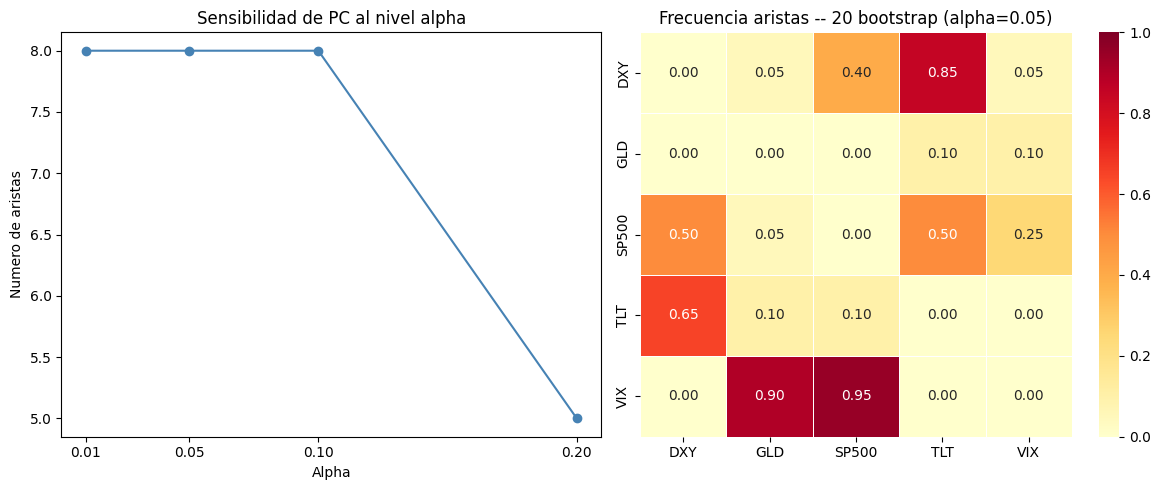

In [38]:
# Define los 4 valores de alpha a probar
alphas = [0.01, 0.05, 0.10, 0.20]
# Para cada alpha ejecuta PC y cuenta cuantas aristas produce el grafo resultante
n_edges = [len(list(PC(data=returns).estimate(variant='stable', ci_test='pearsonr',
           significance_level=a).edges())) for a in alphas]

# Bootstrap: prepara la matriz de conteo de aristas
nodes_b = sorted(returns.columns)
edge_counts = pd.DataFrame(0, index=nodes_b, columns=nodes_b)  # empieza todo a 0
np.random.seed(42)                      # fija semilla para reproducibilidad
for _ in range(20):                     # repite 20 veces
    s = returns.sample(frac=1.0, replace=True)   # muestra bootstrap con reemplazo
    d = PC(data=s).estimate(variant='stable', ci_test='pearsonr', significance_level=0.05)
    for u, v in d.edges():
        edge_counts.loc[u, v] += 1      # suma 1 cada vez que aparece esta arista

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Panel izquierdo: linea de aristas vs alpha
axes[0].plot(alphas, n_edges, marker='o', color='steelblue')
axes[0].set_xlabel('Alpha'); axes[0].set_ylabel('Numero de aristas')
axes[0].set_title('Sensibilidad de PC al nivel alpha'); axes[0].set_xticks(alphas)
# Panel derecho: frecuencia de cada arista en 20 bootstrap (1.0=siempre, 0.0=nunca)
sns.heatmap(edge_counts / 20, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5)
axes[1].set_title('Frecuencia aristas -- 20 bootstrap (alpha=0.05)')
plt.tight_layout(); plt.show()

## 7. Visualizacion interactiva (plotly)

Grafo con zoom y pan en el notebook. Hover muestra causas y efectos de cada nodo.

In [39]:
# Calcula posiciones de los nodos con layout de resortes (seed fijo = reproducible)
pos = nx.spring_layout(dag_pc, seed=42)

fig = go.Figure()
# Dibuja cada arista del DAG como una flecha con anotacion de plotly
for u, v in dag_pc.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]   # coordenadas origen y destino
    fig.add_annotation(x=x1, y=y1, ax=x0, ay=y0, xref='x', yref='y', axref='x', ayref='y',
                       showarrow=True, arrowhead=3, arrowsize=1.5, arrowwidth=2, arrowcolor='gray')

# Dibuja los nodos como puntos con etiquetas de texto y tooltip al hover
fig.add_trace(go.Scatter(
    x=[pos[n][0] for n in dag_pc.nodes()],   # coordenada x de cada nodo
    y=[pos[n][1] for n in dag_pc.nodes()],   # coordenada y de cada nodo
    mode='markers+text', text=list(dag_pc.nodes()), textposition='top center',
    # hover muestra nombre del nodo, sus causas (in) y sus efectos (out)
    hovertext=[f"{n}<br>in: {list(dag_pc.predecessors(n))}<br>out: {list(dag_pc.successors(n))}" for n in dag_pc.nodes()],
    hoverinfo='text', marker=dict(size=28, color='steelblue', line=dict(width=2, color='white'))
))
# Oculta ejes, fondo blanco, titulo descriptivo
fig.update_layout(showlegend=False, height=500, plot_bgcolor='white',
                  xaxis=dict(visible=False), yaxis=dict(visible=False),
                  title='DAG Causal -- PC Algorithm (flechas = direccion causal)')
fig.show()

## 8. EXTRA -- Factor Mirage: sesgo de colisionador

Un colisionador A->C<-B bloquea el camino entre A y B. Controlarlo en una regresion abre ese camino e induce correlacion espuria.

Estructura causal -- PC (2000-2024):
  SP500 -> DXY
  SP500 -> TLT
  SP500 -> VIX
  DXY -> TLT
  DXY -> SP500
  TLT -> DXY
  VIX -> SP500
  VIX -> GLD

Coeficiente GLD sin DXY : -0.0321
Coeficiente GLD con DXY : -0.0477
Diferencia              : -0.0156


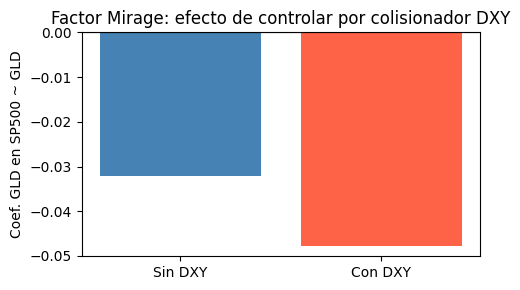

In [40]:
# Imprime las aristas del DAG para identificar posibles colisionadores
print('Estructura causal -- PC (2000-2024):')
for e in dag_pc.edges():
    print(f'  {e[0]} -> {e[1]}')

# Regresion SP500 ~ GLD  sin controlar por DXY
coef_sin = LinearRegression().fit(returns[['GLD']], returns['SP500']).coef_[0]

# Regresion SP500 ~ GLD + DXY  (controlando por posible colisionador)
coef_con = LinearRegression().fit(returns[['GLD', 'DXY']], returns['SP500']).coef_[0]

# Compara los coeficientes: si difieren, DXY esta sesgando la estimacion
print(f'\nCoeficiente GLD sin DXY : {coef_sin:.4f}')
print(f'Coeficiente GLD con DXY : {coef_con:.4f}')
print(f'Diferencia              : {coef_con - coef_sin:.4f}')

# Barplot comparando los dos coeficientes
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Sin DXY', 'Con DXY'], [coef_sin, coef_con], color=['steelblue', 'tomato'])
ax.axhline(0, color='black', linewidth=0.8)  # linea de referencia en cero
ax.set_ylabel('Coef. GLD en SP500 ~ GLD')
ax.set_title('Factor Mirage: efecto de controlar por colisionador DXY')
plt.tight_layout()
plt.show()